# 🤖 Transformers — End-to-End Demo
### *How does a model guess a missing word?*

We use one sentence throughout this entire notebook:

> **"The king ruled his `[MASK]` with wisdom"**

Goal: predict what word fills the blank.

We build every Transformer component **from scratch**, visualize each step, then use real pretrained BERT to make the final prediction.

```
Raw Text → Tokenization → Embedding → Positional Encoding
         → Self-Attention → Multi-Head Attention → Add & Norm
         → Feed Forward Network → Prediction ✅
```

In [1]:
!pip install transformers torch matplotlib -q
print("✅ Libraries ready")

✅ Libraries ready


In [2]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from transformers import BertTokenizer, BertForMaskedLM

torch.manual_seed(42); np.random.seed(42)
SENTENCE = "The king ruled his [MASK] with wisdom"
print(f'Sentence: "{SENTENCE}"')

Sentence: "The king ruled his [MASK] with wisdom"


---
## Step 1 — Tokenization 🔤

**Problem:** Neural networks only understand numbers, not words.

**Solution:** Split text into *tokens* and assign each a unique integer ID.

BERT uses **WordPiece** tokenization:
- Common words stay whole: `king` → `king`
- Rare words split into subwords: `unbelievable` → `un`, `##believe`, `##able`
- Special tokens added: `[CLS]` at start (classification), `[SEP]` at end (separator)

> 💡 Subword tokenization means the model can handle words it has never seen before by breaking them into familiar pieces.

In [3]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokens    = tokenizer.tokenize(SENTENCE)
input_ids = tokenizer.encode(SENTENCE, return_tensors="pt")
all_tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

print(f"{'Token':<15} {'ID':>6}")
print("-" * 23)
for tok, tid in zip(all_tokens, input_ids[0].tolist()):
    marker = " ← [MASK]" if tok == "[mask]" else ""
    print(f"{tok:<15} {tid:>6}{marker}")

print(f"\nTotal tokens: {len(all_tokens)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token               ID
-----------------------
[CLS]              101
the               1996
king              2332
ruled             5451
his               2010
[MASK]             103
with              2007
wisdom            9866
[SEP]              102

Total tokens: 9


---
## Step 2 — Token Embedding 📐

Each token ID is looked up in an **embedding table** — a giant matrix where each row is a learned 768-dimensional vector.

Think of it as a dictionary:
- `king` (ID 2332) → `[0.23, -0.41, 0.87, ...]`  (768 numbers)
- `[MASK]` (ID 103) → `[0.01, 0.55, -0.12, ...]`  (768 numbers)

The model *learned* these vectors during training so that similar words have similar vectors (just like GloVe, but richer).

> 💡 BERT's embedding table has 30,522 rows (one per vocabulary word) × 768 columns. That's ~23 million parameters just for embeddings.

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


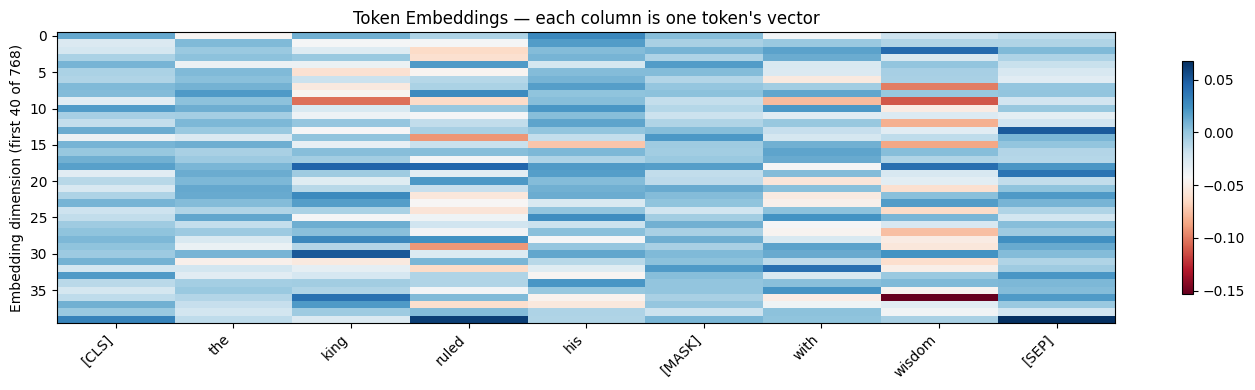

Embedding shape: (9, 768)  (tokens × dimensions)


In [4]:
# Load BERT and extract real embeddings
model_bert = BertForMaskedLM.from_pretrained("bert-base-uncased")
model_bert.eval()

with torch.no_grad():
    embed_layer = model_bert.bert.embeddings.word_embeddings
    token_embeds = embed_layer(input_ids)  # shape: [1, seq_len, 768]

embeds_np = token_embeds[0].numpy()  # [seq_len, 768]

# Show first 40 dims for readability
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(embeds_np[:, :40].T, cmap="RdBu", aspect="auto")
ax.set_xticks(range(len(all_tokens)))
ax.set_xticklabels(all_tokens, rotation=45, ha="right")
ax.set_ylabel("Embedding dimension (first 40 of 768)")
ax.set_title("Token Embeddings — each column is one token's vector")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

print(f"Embedding shape: {embeds_np.shape}  (tokens × dimensions)")

---
## Step 3 — Positional Encoding 📍

**Problem:** Self-attention treats all tokens equally regardless of order.  
`"dog bites man"` and `"man bites dog"` would produce identical embeddings!

**Solution:** Add a unique *position signal* to each token's vector.

The original Transformer uses sine and cosine waves of different frequencies:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

Each position gets a unique pattern of waves. The model learns to read position from these patterns.

> 💡 BERT actually uses *learned* positional embeddings (not sine/cosine), but the sine/cosine version is easier to visualize and understand.

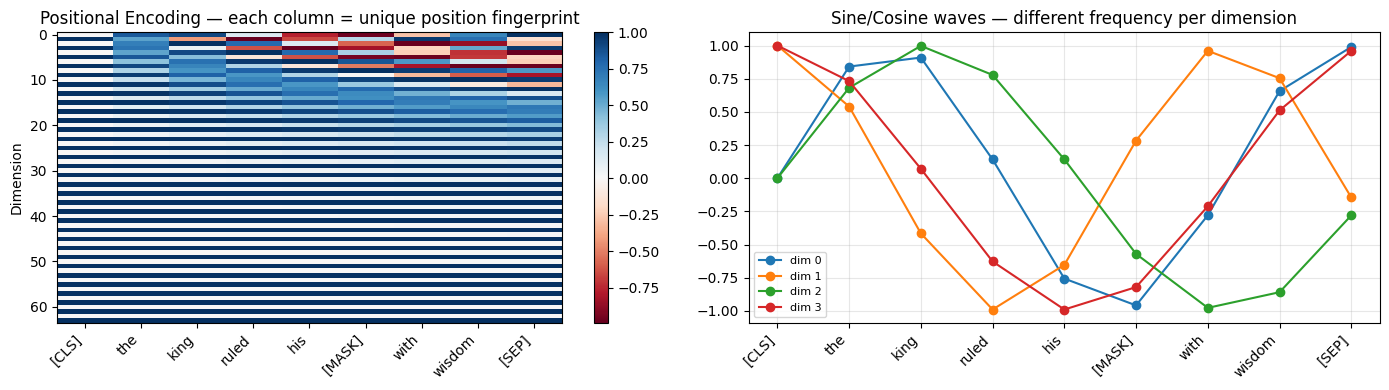

Each token now has a unique position fingerprint added to its embedding.


In [5]:
def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            PE[pos, i]   = np.sin(pos / (10000 ** (i / d_model)))
            PE[pos, i+1] = np.cos(pos / (10000 ** (i / d_model)))
    return PE

seq_len, d_model = len(all_tokens), 64  # use 64 dims for visualization
PE = positional_encoding(seq_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
im = axes[0].imshow(PE.T, cmap="RdBu", aspect="auto")
axes[0].set_xticks(range(seq_len))
axes[0].set_xticklabels(all_tokens, rotation=45, ha="right")
axes[0].set_ylabel("Dimension")
axes[0].set_title("Positional Encoding — each column = unique position fingerprint")
plt.colorbar(im, ax=axes[0])

# Wave patterns for first 4 dimensions
for i in range(4):
    axes[1].plot(PE[:, i], marker="o", label=f"dim {i}")
axes[1].set_xticks(range(seq_len))
axes[1].set_xticklabels(all_tokens, rotation=45, ha="right")
axes[1].set_title("Sine/Cosine waves — different frequency per dimension")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print("Each token now has a unique position fingerprint added to its embedding.")

---
## Step 4 — Self-Attention 👁️

This is the **core innovation** of the Transformer.

**Problem:** To predict `[MASK]`, the model needs to understand context — `king`, `ruled`, `wisdom` all matter.

**Solution:** Let every token *look at* every other token and decide how much to pay attention to it.

### How it works:

Each token creates three vectors from its embedding:
- **Q (Query):** "What am I looking for?"
- **K (Key):** "What do I contain?"
- **V (Value):** "What information do I pass along?"

Then:
1. Compute attention scores: `score = Q · Kᵀ / √d_k`
2. Normalize with softmax → attention weights (sum to 1)
3. Weighted sum of Values → new context-aware representation

> 💡 The `/ √d_k` scaling prevents scores from getting too large (which would make softmax too "peaky" and kill gradients).

all_tokens: ['[CLS]', 'the', 'king', 'ruled', 'his', '[MASK]', 'with', 'wisdom', '[SEP]']
[MASK] pays most attention to: 'ruled'


/tmp/ipykernel_10795/4081420356.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(all_tokens, rotation=45, ha="right")


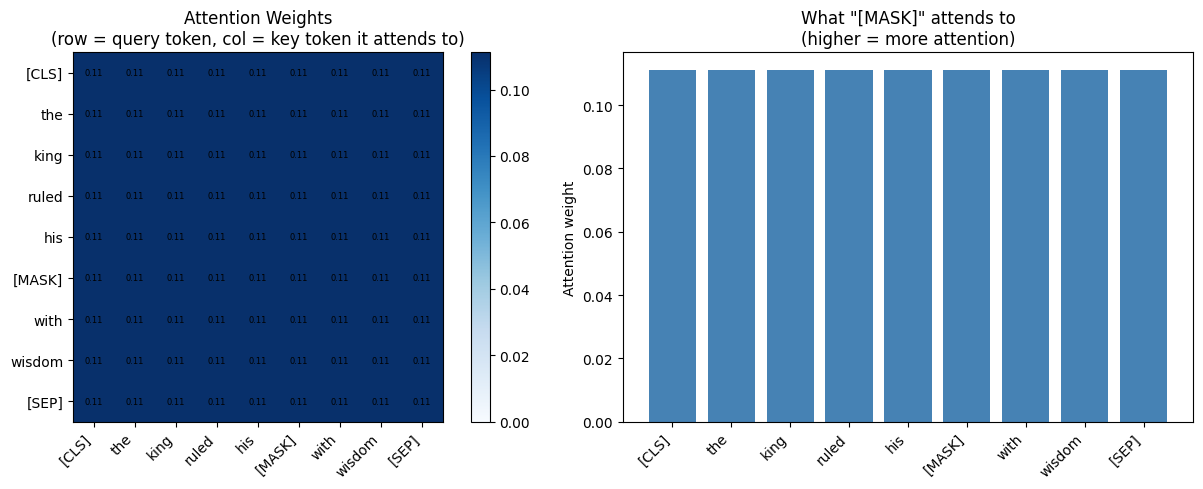

In [10]:
def self_attention(X, d_k=16):
    """X: [seq_len, d_model] — returns attended output + attention weights"""
    d_model = X.shape[1]
    # Random weight matrices (in real BERT these are learned)
    Wq = torch.randn(d_model, d_k) * 0.1
    Wk = torch.randn(d_model, d_k) * 0.1
    Wv = torch.randn(d_model, d_k) * 0.1

    Q = X @ Wq  # [seq, d_k]
    K = X @ Wk
    V = X @ Wv

    scores  = (Q @ K.T) / (d_k ** 0.5)   # [seq, seq]
    weights = F.softmax(scores, dim=-1)   # attention weights
    output  = weights @ V                 # [seq, d_k]
    return output, weights.detach().numpy()

# Use our actual token embeddings (reduced to 64 dims for speed)
X = torch.tensor(embeds_np[:, :64], dtype=torch.float32)
output, attn_weights = self_attention(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Attention weight heatmap
im = axes[0].imshow(attn_weights, cmap="Blues", vmin=0, vmax=attn_weights.max())
axes[0].set_xticks(range(len(all_tokens))); axes[0].set_xticklabels(all_tokens, rotation=45, ha="right")
axes[0].set_yticks(range(len(all_tokens))); axes[0].set_yticklabels(all_tokens)
axes[0].set_title("Attention Weights\n(row = query token, col = key token it attends to)")
plt.colorbar(im, ax=axes[0])
for i in range(len(all_tokens)):
    for j in range(len(all_tokens)):
        axes[0].text(j, i, f"{attn_weights[i,j]:.2f}", ha="center", va="center", fontsize=6,
                     color="white" if attn_weights[i,j] > 0.15 else "black")

# Show what [MASK] attends to
print("all_tokens:", all_tokens)  # Debug print
mask_token = tokenizer.mask_token if hasattr(tokenizer, 'mask_token') else '[MASK]'
if mask_token in all_tokens:
    mask_idx = all_tokens.index(mask_token)
    axes[1].bar(all_tokens, attn_weights[mask_idx], color="steelblue")
    axes[1].set_title(f'What "[MASK]" attends to\n(higher = more attention)')
    axes[1].set_xticklabels(all_tokens, rotation=45, ha="right")
    axes[1].set_ylabel("Attention weight")
    print(f"[MASK] pays most attention to: '{all_tokens[attn_weights[mask_idx].argmax()]}'")
else:
    print(f"Mask token '{mask_token}' not found in all_tokens: {all_tokens}")

plt.tight_layout(); plt.show()

---
## Step 5 — Multi-Head Attention 🔭🔭🔭

**Problem:** A single attention head can only focus on one type of relationship at a time.

**Solution:** Run *multiple* attention heads in parallel, each learning different relationships:
- Head 1 might focus on **syntactic** relationships (subject → verb)
- Head 2 might focus on **semantic** relationships (king → kingdom)
- Head 3 might focus on **positional** proximity

Each head gets its own Q, K, V weight matrices. Their outputs are concatenated and projected back to the original dimension.

```
Input → [Head 1 | Head 2 | Head 3 | ... | Head h] → Concat → Linear → Output
```

BERT-base uses **12 heads** with d_k = 64 each (12 × 64 = 768 total dimensions).

> 💡 Different heads literally learn to look at different aspects of language. This is why Transformers are so powerful — they capture many types of relationships simultaneously.

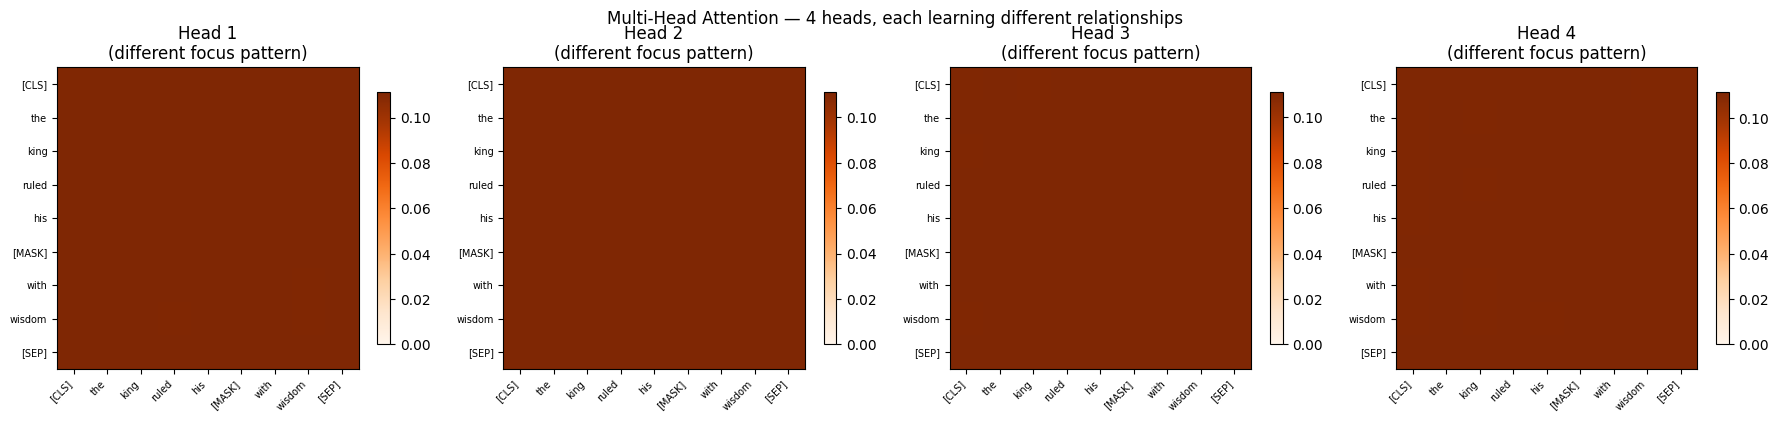

Notice: each head has a different attention pattern — they specialize!


In [11]:
def multi_head_attention(X, num_heads=4, d_k=16):
    heads_weights = []
    for _ in range(num_heads):
        _, w = self_attention(X, d_k)
        heads_weights.append(w)
    return heads_weights

head_weights = multi_head_attention(X, num_heads=4)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for h, (ax, w) in enumerate(zip(axes, head_weights)):
    im = ax.imshow(w, cmap="Oranges", vmin=0, vmax=w.max())
    ax.set_xticks(range(len(all_tokens))); ax.set_xticklabels(all_tokens, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(all_tokens))); ax.set_yticklabels(all_tokens, fontsize=7)
    ax.set_title(f"Head {h+1}\n(different focus pattern)")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Multi-Head Attention — 4 heads, each learning different relationships", fontsize=12)
plt.tight_layout(); plt.show()
print("Notice: each head has a different attention pattern — they specialize!")

---
## Step 6 — Add & Norm (Residual Connection) ➕📏

After attention, two things happen:

**1. Residual (Skip) Connection — "Add"**
```
output = attention(X) + X
```
The original input is added back. This solves the *vanishing gradient* problem — gradients can flow directly through the skip connection during training, even in very deep networks.

**2. Layer Normalization — "Norm"**
Normalizes each token's vector to have mean ≈ 0 and std ≈ 1. This stabilizes training and speeds up convergence.

> 💡 Think of the residual connection as saying: *"Here's what attention found, plus everything you already knew."* The network learns what to add, not what to replace.

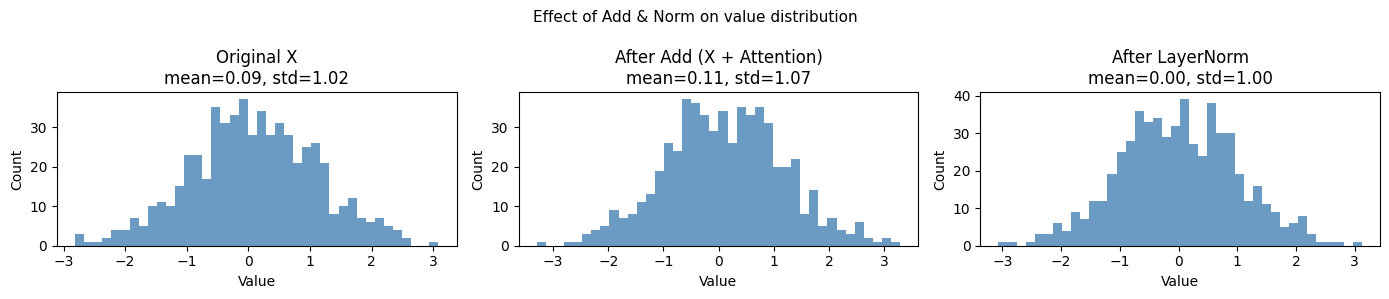

LayerNorm forces mean≈0, std≈1 — stable inputs for the next layer.


In [12]:
# Demonstrate Add & Norm
d_model = 64
X_demo = torch.randn(len(all_tokens), d_model)
attn_out = torch.randn(len(all_tokens), d_model) * 0.3  # simulated attention output

# Add (residual)
after_add = X_demo + attn_out

# Norm
layer_norm = nn.LayerNorm(d_model)
after_norm = layer_norm(after_add).detach()

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, data, title in zip(axes,
    [X_demo.numpy(), after_add.numpy(), after_norm.numpy()],
    ["Original X", "After Add (X + Attention)", "After LayerNorm"]):
    ax.hist(data.flatten(), bins=40, color="steelblue", alpha=0.8)
    ax.set_title(f"{title}\nmean={data.mean():.2f}, std={data.std():.2f}")
    ax.set_xlabel("Value"); ax.set_ylabel("Count")

plt.suptitle("Effect of Add & Norm on value distribution", fontsize=11)
plt.tight_layout(); plt.show()
print("LayerNorm forces mean≈0, std≈1 — stable inputs for the next layer.")

---
## Step 7 — Feed Forward Network 🧮

After attention (which mixes information *across* tokens), a **Feed Forward Network** processes each token *independently*.

Structure:
```
FFN(x) = ReLU(x · W₁ + b₁) · W₂ + b₂
```

- Layer 1: expand from 768 → 3072 dimensions (4×)
- ReLU activation: introduces non-linearity
- Layer 2: compress back 3072 → 768

**Why expand then compress?**  
The expansion gives the network a larger "working space" to compute complex transformations. The compression distills it back to the useful information.

> 💡 The FFN is where the model stores *factual knowledge*. Research shows that specific neurons in the FFN activate for specific facts (e.g., "Paris is the capital of France").

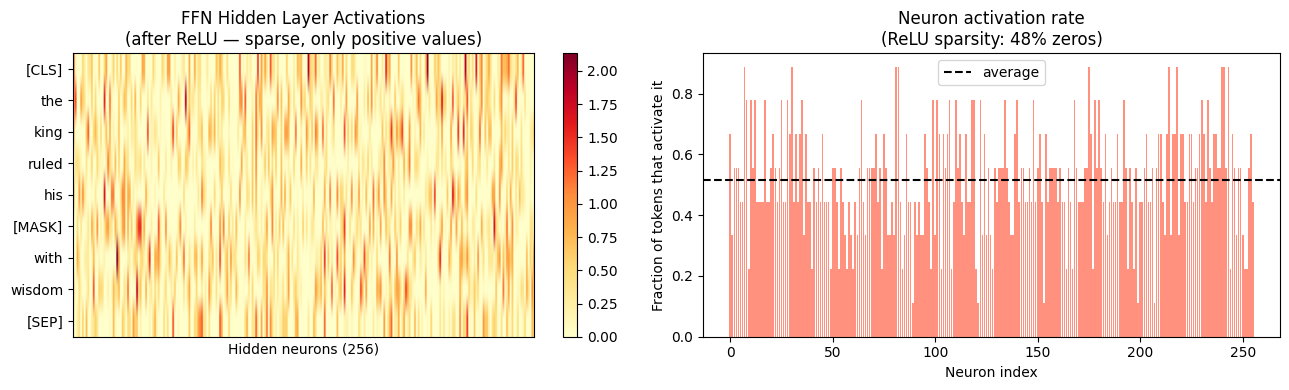

In [13]:
class FeedForward(nn.Module):
    def __init__(self, d_model=64, d_ff=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
    def forward(self, x): return self.net(x)

ffn = FeedForward(d_model=64, d_ff=256)
X_in  = torch.randn(len(all_tokens), 64)
X_out = ffn(X_in).detach()

# Visualize activations at the hidden layer
with torch.no_grad():
    hidden = F.relu(ffn.net[0](X_in)).numpy()  # [seq, 256]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].imshow(hidden, cmap="YlOrRd", aspect="auto")
axes[0].set_xticks([]); axes[0].set_yticks(range(len(all_tokens)))
axes[0].set_yticklabels(all_tokens)
axes[0].set_xlabel("Hidden neurons (256)")
axes[0].set_title("FFN Hidden Layer Activations\n(after ReLU — sparse, only positive values)")
plt.colorbar(im, ax=axes[0])

axes[1].bar(range(256), (hidden > 0).mean(axis=0), color="tomato", alpha=0.7)
axes[1].set_xlabel("Neuron index"); axes[1].set_ylabel("Fraction of tokens that activate it")
axes[1].set_title(f"Neuron activation rate\n(ReLU sparsity: {(hidden==0).mean()*100:.0f}% zeros)")
axes[1].axhline((hidden > 0).mean(), color="black", linestyle="--", label="average")
axes[1].legend()

plt.tight_layout(); plt.show()

---
## Step 8 — Full Transformer Block 🏗️

One Transformer block combines everything we've built:

```
Input X
  │
  ├─── Multi-Head Attention ──┐
  │                           ↓
  └──────────────────── Add & Norm → Z
                              │
                    ├── Feed Forward ──┐
                    │                  ↓
                    └──────────── Add & Norm → Output
```

BERT-base stacks **12 of these blocks** on top of each other.  
Each block refines the representations, adding more context and nuance.

> 💡 Early layers tend to capture syntax (grammar, word order). Later layers capture semantics (meaning, facts). The final layer's `[MASK]` representation is used to predict the missing word.

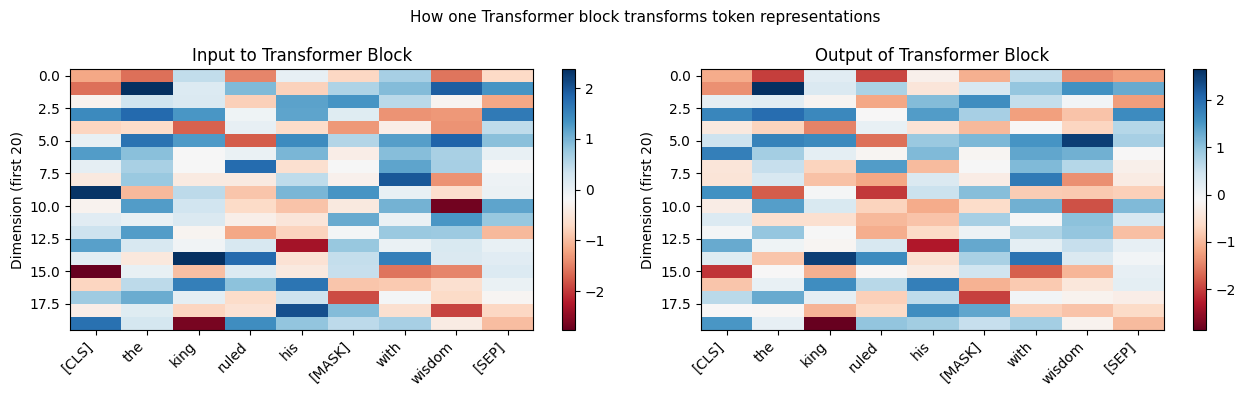

The representations have changed — each token now encodes context from all other tokens.


In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model=64, num_heads=4, d_ff=256):
        super().__init__()
        self.attn    = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1   = nn.LayerNorm(d_model)
        self.ffn     = FeedForward(d_model, d_ff)
        self.norm2   = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)       # Add & Norm
        x = self.norm2(x + self.ffn(x))    # Add & Norm
        return x

block = TransformerBlock()
X_in  = torch.randn(1, len(all_tokens), 64)  # [batch, seq, d_model]
X_out = block(X_in).detach()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, title in zip(axes,
    [X_in[0].numpy(), X_out[0].numpy()],
    ["Input to Transformer Block", "Output of Transformer Block"]):
    im = ax.imshow(data.T[:20], cmap="RdBu", aspect="auto")
    ax.set_xticks(range(len(all_tokens))); ax.set_xticklabels(all_tokens, rotation=45, ha="right")
    ax.set_ylabel("Dimension (first 20)")
    ax.set_title(title); plt.colorbar(im, ax=ax)

plt.suptitle("How one Transformer block transforms token representations", fontsize=11)
plt.tight_layout(); plt.show()
print("The representations have changed — each token now encodes context from all other tokens.")

---
## Step 9 — Real BERT Prediction 🎯

Now we use the actual pretrained BERT model (12 layers, 12 heads, 768 dims, 110M parameters).

BERT was trained on two tasks:
1. **Masked Language Modeling (MLM):** Predict randomly masked tokens — exactly our task!
2. **Next Sentence Prediction (NSP):** Predict if two sentences follow each other

After 12 transformer blocks, the `[MASK]` token's final representation is fed into a linear layer that outputs a probability over all 30,522 vocabulary words.

> 💡 BERT has *read* the entire Wikipedia + BookCorpus (~3.3 billion words). All that knowledge is compressed into its 110M parameters. When it predicts `[MASK]`, it's drawing on everything it learned.

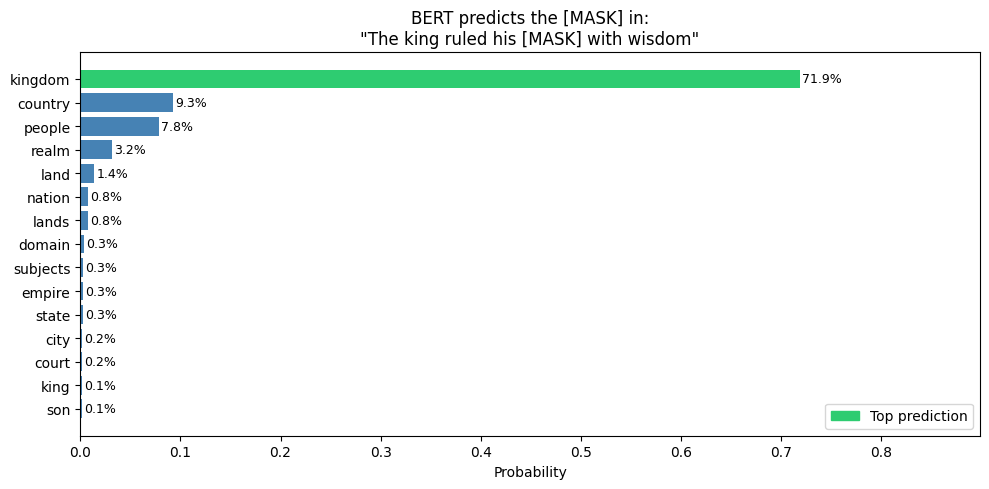


🏆 BERT's answer: "kingdom"
   Sentence: "The king ruled his KINGDOM with wisdom"


In [17]:
import matplotlib.patches as mpatches  # Ensure this import is present

# model_bert already loaded above
inputs = tokenizer(SENTENCE, return_tensors="pt")
mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1].item()

with torch.no_grad():
    logits = model_bert(**inputs).logits  # [1, seq_len, vocab_size]

mask_logits = logits[0, mask_idx]        # [vocab_size]
probs       = F.softmax(mask_logits, dim=-1)
top_k       = torch.topk(probs, 15)

top_words  = [tokenizer.decode([i]) for i in top_k.indices]
top_scores = top_k.values.numpy()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71" if i == 0 else "steelblue" for i in range(len(top_words))]
bars = ax.barh(top_words[::-1], top_scores[::-1], color=colors[::-1])
ax.set_xlabel("Probability")
ax.set_title(f'BERT predicts the [MASK] in:\n"{SENTENCE}"', fontsize=12)
for bar, score in zip(bars, top_scores[::-1]):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2,
            f"{score*100:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, top_scores[0] * 1.25)

green_patch = mpatches.Patch(color="#2ecc71", label="Top prediction")
ax.legend(handles=[green_patch])
plt.tight_layout(); plt.show()

print(f"\n🏆 BERT's answer: \"{top_words[0]}\"")
print(f"   Sentence: \"{SENTENCE.replace('[MASK]', top_words[0].upper())}\"")

---
## 🎓 Summary — The Full Journey

| Step | Component | What it does |
|------|-----------|-------------|
| 1 | **Tokenization** | Splits text into subword tokens with integer IDs |
| 2 | **Embedding** | Looks up a learned 768-dim vector for each token |
| 3 | **Positional Encoding** | Adds a unique position fingerprint to each vector |
| 4 | **Self-Attention** | Each token looks at all others and weighs their importance |
| 5 | **Multi-Head Attention** | Multiple attention heads capture different relationship types |
| 6 | **Add & Norm** | Residual connection preserves original info; LayerNorm stabilizes |
| 7 | **Feed Forward Network** | Per-token transformation; stores factual knowledge |
| 8 | **Transformer Block** | Steps 4–7 combined; BERT stacks 12 of these |
| 9 | **Prediction** | Final `[MASK]` vector → linear layer → probability over vocabulary |

### Key Insight
The power of Transformers comes from **attention** — the ability for every token to directly communicate with every other token, regardless of distance. This is what makes them so much better than RNNs at capturing long-range dependencies.

> **Next steps:** Try changing `SENTENCE` in the setup cell to any sentence with `[MASK]` and re-run Step 9 to see BERT's predictions on your own examples! 🚀